# 01 — Algebra Liniowa i Softmax

Notatki z pierwszego projektu z serii "AI od podstaw".  
Cel: zrozumieć matematyczne fundamenty mechanizmu uwagi (attention) w transformerach.

> Attention to w skrócie: oblicz podobieństwo między wektorami → znormalizuj softmaxem → użyj jako wagi.

## Spis treści

0. Wymagana wiedza wstępna
1. Iloczyn skalarny (Dot Product)
2. Mnożenie macierzy (Matrix Multiplication)
3. Podobieństwo kosinusowe (Cosine Similarity)
4. Softmax
5. Demo: Rdzeń mechanizmu uwagi (Attention Core)
6. Omówienie wyników attention

In [ ]:
!pip install numpy matplotlib

## 0. Wymagana wiedza wstępna

Żeby swobodnie poruszać się po tym materiale, przyda się podstawowa znajomość poniższych zagadnień:

### Algebra liniowa
- **Wektory** — czym są, jak je reprezentować, co oznacza kierunek i długość wektora
- **Norma wektora** — jak mierzyć "długość" wektora ($\|\mathbf{a}\| = \sqrt{\sum a_i^2}$)
- **Macierze** — reprezentacja danych jako siatki liczb, indeksowanie wierszy i kolumn
- **Transpozycja macierzy** — zamiana wierszy z kolumnami ($A^T$)
- **Mnożenie macierzy** — zasada zgodności kształtów (m×k) · (k×n) = (m×n)

### Analiza matematyczna (podstawy)
- **Funkcja wykładnicza** $e^x$ — jej właściwości (zawsze dodatnia, rośnie monotonicznie)
- **Suma szeregu** — sumowanie elementów wektora/tablicy

### Rachunek prawdopodobieństwa (podstawy)
- **Rozkład prawdopodobieństwa** — zbiór wartości nieujemnych sumujących się do 1
- Intuicja: czym różni się "wynik" od "prawdopodobieństwa"

### Geometria
- **Kąt między wektorami** — cosinus kąta jako miara podobieństwa kierunkowego
- Intuicja: kiedy dwa wektory są "podobne" geometrycznie

### Python

#### Podstawy języka
- **Pętle** — `for i in range(n)` do iterowania po indeksach
- **List comprehensions** — `[f(x) for x in lista]` zamiast pętli z `.append()`
- **Funkcje** — definiowanie `def`, parametry, `return`, `assert` do walidacji wejścia
- **Typy wbudowane** — `list`, operacje `sum()`, `max()`, `min()` na listach

#### NumPy
- `np.array([...])` — tworzenie tablicy z listy
- `np.zeros((m, n))` — macierz zer o podanym kształcie
- `np.random.randn(m, n)` — losowa macierz z rozkładu normalnego
- `A.shape` — krotka `(wiersze, kolumny)`
- `A.size` — całkowita liczba elementów
- `np.dot(A, B)` — referencyjne mnożenie/iloczyn skalarny z NumPy
- `np.allclose(A, B)` — porównanie tablic z tolerancją na błędy zmiennoprzecinkowe
- `np.linalg.norm(A)` — norma wektora
- `np.argmax(A)` — indeks największego elementu
- `np.exp(A)` — funkcja wykładnicza element po elemencie

#### Biblioteka standardowa
- `from math import exp, sqrt` — wersje skalarne funkcji matematycznych

Nie trzeba znać tego wszystkiego na pamięć — każde zagadnienie zostanie przypomniane przy odpowiedniej sekcji.

## 1. Iloczyn skalarny (Dot Product)

https://pl.wikipedia.org/wiki/Iloczyn_skalarny

Iloczyn skalarny dwóch wektorów **a** i **b** to suma iloczynów odpowiadających sobie elementów:

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i} a_i \cdot b_i$$

**Co to mierzy?**  
Im wyższy wynik, tym bardziej wektory "wskazują w tym samym kierunku".  
W sieciach neuronowych to podstawowa miara podobieństwa.

**Przykład**

Dane są dwa przykładowe wektory:

$$\mathbf{A} = [1, 2, 3, 4] \qquad \mathbf{B} = [3, 5, 7, 9]$$

Mnożymy odpowiadające sobie elementy i sumujemy:

$$\mathbf{A} \cdot \mathbf{B} = (1 \cdot 3) + (2 \cdot 5) + (3 \cdot 7) + (4 \cdot 9)$$

$$= 3 + 10 + 21 + 36$$

$$= 70$$

In [4]:
import numpy as np

def dot_product(A, B):
    assert A.size == B.size, "incompatible vectors"
    return sum([A[x] * B[x] for x in range(A.size)])

A = np.array([1, 2, 3, 4])
B = np.array([3, 5, 7, 9])

result = dot_product(A, B)
expected = np.dot(A, B)
print(f"result = {result}, expected = {expected}, is_close = {np.isclose(result, expected)}")

result = 70, expected = 70, is_close = True


## 2. Mnożenie macierzy (Matrix Multiplication)

https://en.wikipedia.org/wiki/Matrix_multiplication

Mnożenie macierzy **A** (m×k) przez **B** (k×n) daje macierz **C** (m×n).  
Każdy element wynikowy to iloczyn skalarny wiersza z **A** i kolumny z **B**:

$$C[i, j] = \sum_{k} A[i, k] \cdot B[k, j]$$

**Warunek:** liczba kolumn **A** musi równać się liczbie wierszy **B**.

**Dlaczego to ważne?**  
Każda warstwa sieci neuronowej to mnożenie macierzy — wejście × wagi.

**Przykład krok po kroku**

Weźmy małe macierze (2×3) · (3×2):

$$A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix} \qquad B = \begin{bmatrix} 7 & 8 \\ 9 & 10 \\ 11 & 12 \end{bmatrix}$$

Wynik **C** będzie miał kształt (2×2). Liczymy każdy element:

$$C[0,0] = (1 \cdot 7) + (2 \cdot 9) + (3 \cdot 11) = 7 + 18 + 33 = 58$$

$$C[0,1] = (1 \cdot 8) + (2 \cdot 10) + (3 \cdot 12) = 8 + 20 + 36 = 64$$

$$C[1,0] = (4 \cdot 7) + (5 \cdot 9) + (6 \cdot 11) = 28 + 45 + 66 = 139$$

$$C[1,1] = (4 \cdot 8) + (5 \cdot 10) + (6 \cdot 12) = 32 + 50 + 72 = 154$$

$$C = \begin{bmatrix} 58 & 64 \\ 139 & 154 \end{bmatrix}$$


Matplotlib is building the font cache; this may take a moment.


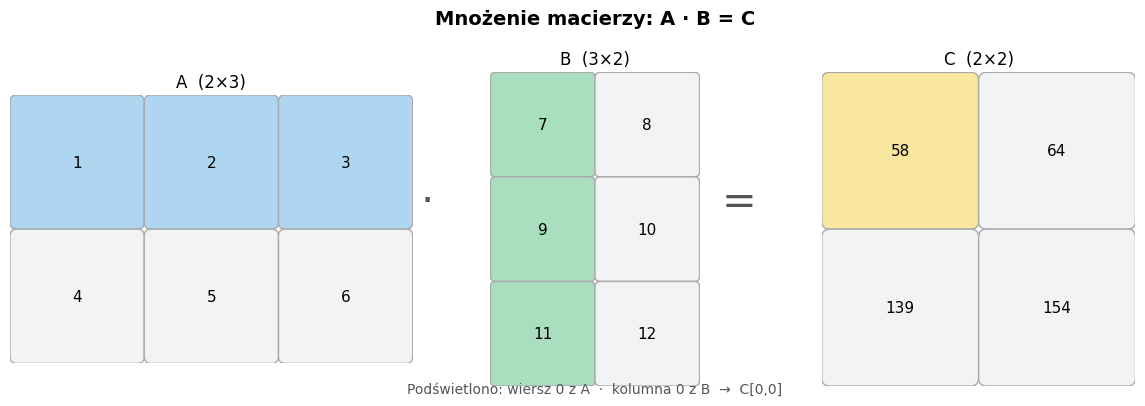

C[0,0] = wiersz 0 z A · kolumna 0 z B = [1 2 3] · [ 7  9 11] = 58
C =
[[ 58  64]
 [139 154]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_matmul(A, B):
    C = A @ B
    a_rows, a_cols = A.shape
    b_rows, b_cols = B.shape

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle("Mnożenie macierzy: A · B = C", fontsize=14, fontweight='bold')

    # Kolory dla podświetlenia aktywnego wiersza/kolumny
    highlight_row, highlight_col = 0, 0

    for ax, matrix, title, highlight_axis in zip(
        axes,
        [A, B, C],
        [f"A  ({a_rows}×{a_cols})", f"B  ({b_rows}×{b_cols})", f"C  ({a_rows}×{b_cols})"],
        ['row', 'col', 'cell']
    ):
        rows, cols = matrix.shape
        ax.set_title(title, fontsize=12)
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
        ax.set_aspect('equal')
        ax.axis('off')

        for i in range(rows):
            for j in range(cols):
                # Podświetl: wiersz 0 w A, kolumnę 0 w B, komórkę [0,0] w C
                if highlight_axis == 'row' and i == highlight_row:
                    color = '#AED6F1'
                elif highlight_axis == 'col' and j == highlight_col:
                    color = '#A9DFBF'
                elif highlight_axis == 'cell' and i == highlight_row and j == highlight_col:
                    color = '#F9E79F'
                else:
                    color = '#F2F3F4'

                rect = patches.FancyBboxPatch(
                    (j + 0.05, rows - i - 0.95), 0.9, 0.9,
                    boxstyle="round,pad=0.05",
                    linewidth=1, edgecolor='#AAA', facecolor=color
                )
                ax.add_patch(rect)
                ax.text(j + 0.5, rows - i - 0.5, f"{matrix[i, j]:.0f}",
                        ha='center', va='center', fontsize=11)

    # Strzałki między macierzami
    fig.text(0.36, 0.5, '·', fontsize=30, ha='center', va='center', color='#555')
    fig.text(0.62, 0.5, '=', fontsize=30, ha='center', va='center', color='#555')

    # Legenda
    fig.text(0.5, 0.02,
             "Podświetlono: wiersz 0 z A  ·  kolumna 0 z B  →  C[0,0]",
             ha='center', fontsize=10, color='#555')

    plt.tight_layout()
    plt.show()

# Przykład z notatki
A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[7,  8],
              [9,  10],
              [11, 12]])

plot_matmul(A, B)
print(f"C[0,0] = wiersz 0 z A · kolumna 0 z B = {A[0]} · {B[:,0]} = {A[0] @ B[:,0]}")
print(f"C =\n{A @ B}")


In [8]:
import numpy as np

def matmul(A, B):
    a_rows, a_cols = A.shape
    b_rows, b_cols = B.shape
    assert a_cols == b_rows, "incompatible shapes"
    
    C = np.zeros((a_rows, b_cols))
    for i in range(a_rows):
        for j in range(b_cols):
            for k in range(a_cols):
                C[i, j] += A[i, k] * B[k, j]
                
    return C


A = np.random.randn(3, 4)
B = np.random.randn(4, 2)
print(f"A = {A}")
print(f"B = {B}")

result = matmul(A, B)
expected = np.dot(A, B)
allclose = np.allclose(result, expected)
print(f"result = {result}")
print(f"expected = {expected}")
print(f"allclose = {allclose}")

A = [[ 1.34612443 -1.04034656 -1.13448935 -0.43575997]
 [ 0.43858011 -0.61208949 -0.0688813   2.07351743]
 [-0.19310271 -0.0630185  -0.43253681 -0.35342947]]
B = [[-0.04302158  0.71783359]
 [ 0.27589176  0.63172798]
 [ 0.91194553 -0.0409627 ]
 [ 1.3677038  -0.4062518 ]]
result = [[-1.9755185   0.53257732]
 [ 2.58540282 -0.91139515]
 [-0.88691554 -0.01712693]]
expected = [[-1.9755185   0.53257732]
 [ 2.58540282 -0.91139515]
 [-0.88691554 -0.01712693]]
allclose = True


## 3. Podobieństwo kosinusowe (Cosine Similarity)

Iloczyn skalarny zależy od długości wektorów — długi wektor da duży wynik nawet jeśli kierunki się różnią.  
Podobieństwo kosinusowe normalizuje to przez podzielenie przez normy obu wektorów:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

Wynik zawsze mieści się w przedziale **[-1, 1]**:
- **1** → wektory identyczne kierunkowo
- **0** → wektory prostopadłe (brak podobieństwa)
- **-1** → wektory przeciwne

**W NLP:** wektory słów o podobnym znaczeniu mają wysokie podobieństwo kosinusowe.

**Przykład krok po kroku**

Wektory z kodu (uproszczone do 2D żeby można było narysować):

$$\mathbf{A} = [2, 3] \qquad \mathbf{B} = [3, 4]$$

**Krok 1 — iloczyn skalarny:**

$$\mathbf{A} \cdot \mathbf{B} = (2 \cdot 3) + (3 \cdot 4) = 6 + 12 = 18$$

**Krok 2 — normy:**

$$\|\mathbf{A}\| = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} \approx 3.606$$

$$\|\mathbf{B}\| = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$

**Krok 3 — podobieństwo kosinusowe:**

$$\cos(\theta) = \frac{18}{3.606 \cdot 5} = \frac{18}{18.028} \approx 0.9985$$

Wynik bliski **1** — wektory wskazują niemal w tym samym kierunku.


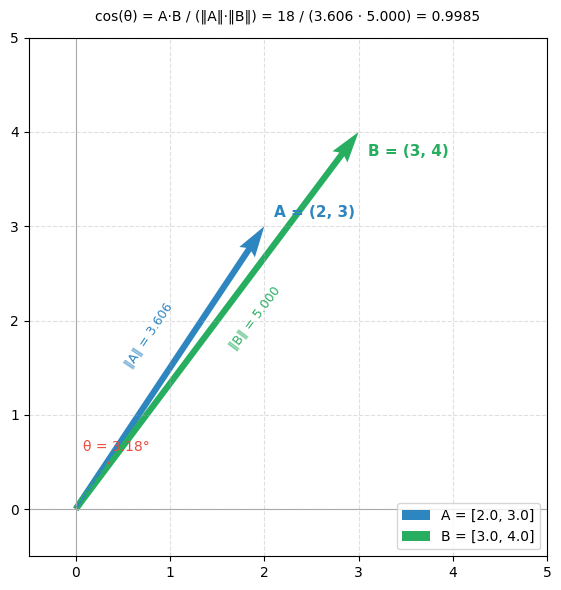

A · B        = 18
‖A‖          = 3.6056
‖B‖          = 5.0000
cos(θ)       = 0.9985
kąt θ        = 3.18°


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

A = np.array([2.0, 3.0])
B = np.array([3.0, 4.0])

dot = A @ B
norm_a = np.sqrt(A @ A)
norm_b = np.sqrt(B @ B)
cos_sim = dot / (norm_a * norm_b)
angle_rad = np.arccos(np.clip(cos_sim, -1, 1))
angle_deg = np.degrees(angle_rad)

fig, ax = plt.subplots(figsize=(6, 6))

# Wektory
ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1,
          color='#2E86C1', width=0.012, label=f'A = {A.tolist()}')
ax.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1,
          color='#27AE60', width=0.012, label=f'B = {B.tolist()}')

# Etykiety końców wektorów
ax.text(A[0] + 0.1, A[1] + 0.1, f'A = ({A[0]:.0f}, {A[1]:.0f})',
        color='#2E86C1', fontsize=11, fontweight='bold')
ax.text(B[0] + 0.1, B[1] - 0.25, f'B = ({B[0]:.0f}, {B[1]:.0f})',
        color='#27AE60', fontsize=11, fontweight='bold')

# Długości wektorów (linie przerywane)
ax.annotate('', xy=(A[0], A[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-', color='#2E86C1',
                            linestyle='dashed', lw=1.2))
ax.text(A[0]/2 - 0.5, A[1]/2, f'‖A‖ = {norm_a:.3f}',
        color='#2E86C1', fontsize=9, rotation=np.degrees(np.arctan2(A[1], A[0])))

ax.text(B[0]/2 + 0.1, B[1]/2 - 0.3, f'‖B‖ = {norm_b:.3f}',
        color='#27AE60', fontsize=9, rotation=np.degrees(np.arctan2(B[1], B[0])))

# Łuk kąta
theta1 = np.degrees(np.arctan2(A[1], A[0]))
theta2 = np.degrees(np.arctan2(B[1], B[0]))
arc = mpatches.Arc((0, 0), 1.2, 1.2, angle=0,
                   theta1=min(theta1, theta2), theta2=max(theta1, theta2),
                   color='#E74C3C', lw=1.5)
ax.add_patch(arc)

# Etykieta kąta
mid_angle = np.radians((theta1 + theta2) / 2)
ax.text(0.75 * np.cos(mid_angle), 0.75 * np.sin(mid_angle),
        f'θ = {angle_deg:.2f}°', color='#E74C3C', fontsize=10, ha='center')

# Wynik
ax.set_title(
    f'cos(θ) = A·B / (‖A‖·‖B‖) = {dot:.0f} / ({norm_a:.3f} · {norm_b:.3f}) = {cos_sim:.4f}',
    fontsize=10, pad=12
)

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.axhline(0, color='#AAA', lw=0.8)
ax.axvline(0, color='#AAA', lw=0.8)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print(f"A · B        = {dot:.0f}")
print(f"‖A‖          = {norm_a:.4f}")
print(f"‖B‖          = {norm_b:.4f}")
print(f"cos(θ)       = {cos_sim:.4f}")
print(f"kąt θ        = {angle_deg:.2f}°")


In [10]:
def norm(A):
    x = 0
    for n in range(A.size):
        x += A[n] * A[n]
    return np.sqrt(x)

def cosine_similarity(A, B):
    return dot_product(A, B) / (norm(A) * norm(B))

# Przykład: które dwa wektory są najbardziej podobne?
krol   = np.array([0.9, 0.1, 0.8])
krolowa = np.array([0.85, 0.2, 0.75])
samochod = np.array([0.1, 0.9, 0.2])

print(f"król ↔ królowa:    {cosine_similarity(krol, krolowa):.4f}")
print(f"król ↔ samochód:   {cosine_similarity(krol, samochod):.4f}")
print(f"królowa ↔ samochód: {cosine_similarity(krolowa, samochod):.4f}")


król ↔ królowa:    0.9958
król ↔ samochód:   0.3034
królowa ↔ samochód: 0.3888


## 4. Softmax

Softmax zamienia wektor liczb (tzw. *logity*) w rozkład prawdopodobieństwa — wszystkie wartości są dodatnie i sumują się do 1.

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Stabilność numeryczna:**  
Dla dużych wartości `x` wyrażenie `e^x` może przepełnić float.  
Trick: odejmujemy `max(x)` przed potęgowaniem — wynik matematycznie identyczny, ale bezpieczny:

$$\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}$$

---

### Przykład krok po kroku

Wejście z kodu: $x = [2.0,\ 1.0,\ 0.5]$

**Krok 1 — odejmujemy max (stabilność numeryczna):**

$$\max(x) = 2.0$$

$$x' = [2.0 - 2.0,\ 1.0 - 2.0,\ 0.5 - 2.0] = [0.0,\ -1.0,\ -1.5]$$

**Krok 2 — potęgujemy:**

$$e^{0.0} = 1.0000$$
$$e^{-1.0} \approx 0.3679$$
$$e^{-1.5} \approx 0.2231$$

**Krok 3 — sumujemy:**

$$S = 1.0000 + 0.3679 + 0.2231 = 1.5910$$

**Krok 4 — dzielimy każdy element przez sumę:**

$$\text{softmax}(x_0) = \frac{1.0000}{1.5910} \approx 0.6285$$

$$\text{softmax}(x_1) = \frac{0.3679}{1.5910} \approx 0.2312$$

$$\text{softmax}(x_2) = \frac{0.2231}{1.5910} \approx 0.1403$$

**Wynik:** $[0.6285,\ 0.2312,\ 0.1403]$

Suma: $0.6285 + 0.2312 + 0.1403 = 1.0$ ✓  
Największy logit (2.0) dostał największą wagę (0.6285) ✓


In [14]:
from math import exp

def softmax(arr):
    norm_arr = [x - max(arr) for x in arr]   # stabilność numeryczna
    exp_arr = [exp(x) for x in norm_arr]
    sum_exp = sum(exp_arr)
    return [x / sum_exp for x in exp_arr]

logity = [2.0, 1.0, 0.5]
wynik = softmax(logity)

print(f"Wejście:  {logity}")
print(f"Wyjście:  {[round(x, 4) for x in wynik]}")
print(f"Suma:     {sum(wynik):.6f}  ← musi być 1.0")
print(f"Najwyższy wynik dla indeksu: {wynik.index(max(wynik))} (tak samo jak w wejściu)")


Wejście:  [2.0, 1.0, 0.5]
Wyjście:  [0.6285, 0.2312, 0.1402]
Suma:     1.000000  ← musi być 1.0
Najwyższy wynik dla indeksu: 0 (tak samo jak w wejściu)


## 5. Demo: Rdzeń mechanizmu uwagi (Attention Core)

Mając te cztery operacje, możemy zasymulować jak działa uwaga w transformerze:

1. Mamy kilka wektorów (np. reprezentacje słów w zdaniu)
2. Obliczamy podobieństwo każdego wektora do każdego innego (iloczyn skalarny)
3. Normalizujemy softmaxem → dostajemy wagi uwagi
4. Obliczamy ważoną sumę wektorów

To jest dokładnie to, co robi mechanizm self-attention.


In [24]:
np.random.seed(42)
n_wektorow = 4
dim = 8

# Symulowane embeddingi słów
wektory = np.random.randn(n_wektorow, dim)
print(f"Wektory:")
for i, row in enumerate(wektory):
    print(f"  vector {i}: {[float(round(w, 3)) for w in row]}")

# Macierz podobieństwa: każdy wiersz to podobieństwo jednego wektora do wszystkich
macierz_podobienstwa = matmul(wektory, wektory.T)  # (4, 4)
print(f"\nMacierz podobieństwa:")
for i, row in enumerate(macierz_podobienstwa):
    print(f"  vector {i}: {[float(round(w, 3)) for w in row]}")

wagi_uwagi = np.array([softmax(row) for row in macierz_podobienstwa])
print("\nWagi uwagi (po softmax, każdy wiersz sumuje się do 1):")
for i, row in enumerate(wagi_uwagi):
    print(f"  vector {i}: {[float(round(w, 3)) for w in row]}")


# Ważona suma: dla każdego słowa oblicz jego "kontekstową" reprezentację
wynik_attention = matmul(wagi_uwagi, wektory)  # (4, 8)
print(f"Wektory (po attention):")
for i, row in enumerate(wynik_attention):
    print(f"  vector {i}: {[float(round(w, 3)) for w in row]}")

Wektory:
  vector 0: [0.497, -0.138, 0.648, 1.523, -0.234, -0.234, 1.579, 0.767]
  vector 1: [-0.469, 0.543, -0.463, -0.466, 0.242, -1.913, -1.725, -0.562]
  vector 2: [-1.013, 0.314, -0.908, -1.412, 1.466, -0.226, 0.068, -1.425]
  vector 3: [-0.544, 0.111, -1.151, 0.376, -0.601, -0.292, -0.602, 1.852]

Macierz podobieństwa:
  vector 0: [6.197, -4.082, -4.563, 0.221]
  vector 1: [-4.082, 7.957, 3.196, 1.083]
  vector 2: [-4.563, 3.196, 8.177, -2.393]
  vector 3: [0.221, 1.083, -2.393, 6.013]

Wagi uwagi (po softmax, każdy wiersz sumuje się do 1):
  vector 0: [0.997, 0.0, 0.0, 0.003]
  vector 1: [0.0, 0.99, 0.008, 0.001]
  vector 2: [0.0, 0.007, 0.993, 0.0]
  vector 3: [0.003, 0.007, 0.0, 0.99]

Kształt wyjścia attention: (4, 8)
Wektory (po attention):
  vector 0: [0.494, -0.138, 0.643, 1.52, -0.235, -0.234, 1.574, 0.77]
  vector 1: [-0.474, 0.54, -0.468, -0.473, 0.251, -1.897, -1.709, -0.567]
  vector 2: [-1.009, 0.316, -0.905, -1.406, 1.457, -0.237, 0.055, -1.419]
  vector 3: [-0.541,

## 6. Omówienie wyników attention

### Wektory wejściowe

Mamy 4 losowe wektory 8-wymiarowe — symulują embeddingi słów w zdaniu.  
Na tym etapie każdy wektor "nie wie nic" o pozostałych.

---

### Macierz podobieństwa (dot products)

```
          v0      v1      v2      v3
v0  [  6.197  -4.082  -4.563   0.221 ]
v1  [ -4.082   7.957   3.196   1.083 ]
v2  [ -4.563   3.196   8.177  -2.393 ]
v3  [  0.221   1.083  -2.393   6.013 ]
```

- Wartości na **przekątnej** są największe — każdy wektor jest najbardziej podobny do samego siebie. To zawsze prawda.
- **v1 ↔ v2** mają wynik `3.196` — jedyna para z wyraźnym podobieństwem między różnymi wektorami.
- **v0 ↔ v1** i **v0 ↔ v2** mają wartości ujemne — te wektory wskazują w przeciwnych kierunkach, są "przeciwstawne".

---

### Wagi uwagi (po softmax)

```
          v0     v1     v2     v3
v0  [ 0.997  0.000  0.000  0.003 ]
v1  [ 0.000  0.990  0.008  0.001 ]
v2  [ 0.000  0.007  0.993  0.000 ]
v3  [ 0.003  0.007  0.000  0.990 ]
```

Softmax bardzo mocno "zaostrzył" rozkład — prawie cała waga trafia do jednego wektora.  
Dzieje się tak dlatego, że różnice między logitami są duże (np. `6.197` vs `-4.082`).  
Softmax jest czuły na te różnice — eksponencja wyolbrzymia przewagi.

Każdy wiersz czyta się jako: *"ile uwagi poświęcam każdemu wektorowi?"*

- **v0** patrzy prawie wyłącznie na siebie (`0.997`) — jest bardzo odizolowany od reszty
- **v1** skupia się na sobie (`0.990`), trochę na v2 (`0.008`) — co ma sens, bo v1↔v2 miały najwyższe podobieństwo spośród różnych par
- **v2** analogicznie — skupia się na sobie (`0.993`), odrobinę na v1 (`0.007`)
- **v3** skupia się na sobie (`0.990`), minimalnie na v1 i v0

---

### Wektory po attention (ważona suma)

Wektory wyjściowe są niemal identyczne z wejściowymi — np.:

```
v0 wejście: [ 0.497, -0.138,  0.648,  1.523, ...]
v0 wyjście: [ 0.494, -0.138,  0.643,  1.520, ...]
```

To bezpośrednia konsekwencja wag uwagi: skoro `v0` przypisał sobie wagę `0.997`,  
jego wyjście to w `99.7%` on sam, a tylko w `0.3%` v3.  
Gdyby wagi były bardziej równomierne (np. `[0.25, 0.25, 0.25, 0.25]`),  
wyjście byłoby średnią wszystkich wektorów — wektor "zmieszałby się" z kontekstem.

---

### Kluczowy wniosek

W tym przykładzie wektory były losowe i bardzo od siebie różne, więc attention  
nie "przepłynął" między nimi — każdy token skupił się na sobie.

W prawdziwym transformerze wektory Q, K, V są wyuczone tak, żeby podobne  
tokeny faktycznie "przyciągały" swoją uwagę — i wtedy wyjście naprawdę  
miesza informacje z różnych pozycji w zdaniu.


## Podsumowanie

| Operacja | Wzór | Rola w attention |
|---|---|---|
| Iloczyn skalarny | $\mathbf{a} \cdot \mathbf{b} = \sum a_i b_i$ | Miara podobieństwa Q·K |
| Mnożenie macierzy | $C[i,j] = \sum_k A[i,k] \cdot B[k,j]$ | Obliczanie wszystkich podobieństw naraz |
| Podobieństwo kosinusowe | $\frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$ | Normalizacja podobieństwa |
| Softmax | $\frac{e^{x_i}}{\sum e^{x_j}}$ | Zamiana wyników na wagi (rozkład prawdopodobieństwa) |

**Następny krok:** Project 02 — backpropagation i gradienty.
